In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_m = pd.read_csv("../data_files/executions.csv")
df_h = pd.read_csv("../data_files/historical_execution_data.txt")

In [2]:
print(df_m.head())

  First Name   Last Name Middle Name(s) Suffix   Race   Sex  Age  \
0       Gary     Gilmore           Mark    NaN  White  Male   36   
1       John  Spenkelink            NaN    NaN  White  Male   30   
2      Jesse      Bishop            NaN    NaN  White  Male   46   
3     Steven        Judy        Timothy    NaN  White  Male   24   
4      Frank     Coppola            NaN    NaN  White  Male   38   

  Foreign National Juvenile Federal  ... Number of Asian Male Victims  \
0               No       No      No  ...                            0   
1               No       No      No  ...                            0   
2               No       No      No  ...                            0   
3               No       No      No  ...                            0   
4               No       No      No  ...                            0   

  Number of Native American Male Victims Number of Other Race Male Victims  \
0                                      0                                 0

In [3]:
df_h.head()

,V5,V6,V7,V10,V11,V12,V13,V14,V16,V19,V21
0,1,,NORMAN ELI,1,1,19,12,1812,1,1,250
1,1,,WOODS JOHN,44,4,6,2,1814,1,1,616
2,2,,GAMARRA CHARLES,13,1,19,5,1820,1,1,
3,2,,DESAYAS VICTORIANO,1,1,19,5,1820,1,1,
4,2,,NOREAGO FRANCISCO,1,1,30,5,1822,1,1,187


In [4]:
col_to_move = df_h.pop('V19')
df_h.insert(1, 'V19', col_to_move)

In [5]:
df_h.columns = ['race', 'sex', 'age', 'name', 'crime_com', 'exec_method', 'date_day', 'date_month', 'date_year', 'state', 'off_occ']

In [6]:
df_h = df_h.sort_values(by='date_year')

In [7]:
df_h['age'] = pd.to_numeric(df_h['age'], errors='coerce').fillna(0).astype(int)
df_h['race'] = df_h['race'].replace({
    '1': 'White',
    '2': 'Black',
    '3': 'Native Am',
    '4': 'Asian-Pac-Il',
    '5': 'Hispanic',
    '6': 'Other',
    ' ': 'Unknown'
    })
df_h['sex'] = df_h['sex'].replace({'1': 'Male', '2': 'Female', ' ': 'Unknown'})

In [8]:
df_h['crime_com'] = df_h['crime_com'].str.strip()
df_h['crime_com'] = df_h['crime_com'].replace({
    '1': 'Murder',
    '2': 'Rape',
    '3': 'Criminal Assault',
    '4': 'HouseBrkng-Burgl',
    '5': 'Horse Stealing',
    '6': 'Consp to Murder',
    '7': 'Treason',
    '8': 'Slave Revolt',
    '9': 'Witchcraft',
    '10': 'Robbery-Murder',
    '11': 'Rape-Murder',
    '12': 'Piracy',
    '13': 'Accessory to Mur',
    '14': 'Desertion',
    '15': 'Robbery',
    '16': 'Arson',
    '17': 'Guerilla Activity',
    '18': 'Spying-Espionage',
    '19': 'Murder-Rape-Rob',
    '20': 'Burg-Att Rape',
    '21': 'Rioting',
    '22': 'Attempted Rape',
    '23': 'Murder-Burglary',
    '24': 'Kidnap-Murder',
    '25': 'Kidnap-Murder-Rob',
    '26': 'Arson-Murder',
    '27': 'Rape-Robbery',
    '28': 'Kidnapping',
    '29': 'Prisn Brk-Kidnap',
    '30': 'Sodmy-Buggry-Bst',
    '31': 'Adultery',
    '33': 'Poisoning',
    '35': 'Concealing Birth',
    '36': 'Unspec Felony',
    '37': 'Aid Runaway Slave',
    '39': 'Counterfeiting',
    '40': 'Attempted Murder',
    '41': 'Forgery',
    '43': 'Theft-Stealing',
    '44': 'Other',
    '': 'Unknown',
})

In [9]:
df_h['exec_method'] = df_h['exec_method'].str.strip()
df_h['exec_method'] = df_h['exec_method'].replace({
    '1': 'Hanging',
    '2': 'Electrocution',
    '3': 'Asphyxiation-Gas',
    '4': 'Shot',
    '5': 'Injection',
    '6': 'Pressing',
    '8': 'Break on Wheel',
    '10': 'Burned',
    '11': 'Hung in Chains',
    '13': 'Bludgeoned',
    '14': 'Gibbetted',
    '15': 'Other',
    '': 'Unknown'
})

In [10]:
df_h['off_occ'] = df_h['off_occ'].str.strip()
df_h['off_occ'] = df_h['off_occ'].replace({
    '610': 'Slave',
    '355': 'Laborer',
    '236': 'Farm Hand',
    '241': 'Farmer',
    '160': 'Convict',
    '224': 'Ex Convict',
    '237': 'Farm Laborer',
    '465': 'Parolee',
    '417': 'Miner',
    '616': 'Soldier',
    '272': 'Gangster',
    '220': 'Escaped Convict',
    '591': 'Seaman',
    '173': 'Criminal',
    '475': 'Pirate',
    '654': 'Tenant Farmer',
    '271': 'Gang Member',
    '108': 'Carpenter',
    '328': 'Housewife',
    '689': 'Truck Driver',
    '530': 'Railroad Worker',
    '259': 'Freedman',
    '': 'Unknown'})

In [11]:
df_h['state'] = df_h['state'].astype(str)
df_h['state'] = df_h['state'].replace({
'1': 'AL',
'2': 'AK',
'4': 'AZ',
'5': 'AR',
'6': 'CA',
'8': 'CO',
'9': 'CT',
'10': 'DE',
'11': 'W.D.C.',
'12': 'FL',
'13': 'GA',
'15': 'HI',
'16': 'ID',
'17': 'IL',
'18': 'IN',
'19': 'IA',
'20': 'KS',
'21': 'KY',
'22': 'LA',
'23': 'ME',
'24': 'MD',
'25': 'MA',
'26': 'MI',
'27': 'MN',
'28': 'MS',
'29': 'MO',
'30': 'MT',
'31': 'NE',
'32': 'NV',
'33': 'NH',
'34': 'NJ',
'35': 'NM',
'36': 'NY',
'37': 'NC',
'38': 'ND',
'39': 'OH',
'40': 'OK',
'41': 'OR',
'42': 'PA',
'44': 'RI',
'45': 'SC',
'46': 'SD',
'47': 'TN',
'48': 'TX',
'49': 'UT',
'50': 'VT',
'51': 'VA',
'53': 'WA',
'54': 'WV',
'55': 'WI',
'56': 'WY'})

In [ ]:
df_h_pre1977 = df_h[df_h['date_year'] < 1977]
df_h_pre1977.tail()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ,execution_date
4388,White,Male,23,YORK GEORGE,Robbery-Murder,Hanging,22,6,1965,KS,Soldier,1965-06-22
707,White,Male,33,BOWEN WILLIAM JR,Murder,Electrocution,15,1,1965,AL,467,1965-01-15
9987,White,Male,30,FRENCH JAMES,Murder,Electrocution,10,8,1966,OK,Convict,1966-08-10
2120,Hispanic,Male,48,MONGE LUIS,Murder,Asphyxiation-Gas,2,6,1967,CO,12,1967-06-02
2019,Black,Male,37,MITCHELL AARON,Murder,Asphyxiation-Gas,12,4,1967,CA,460,1967-04-12


In [13]:
df_m = df_m.drop(columns=['Number of White Male Victims',
       'Number of Black Male Victims', 'Number of Latino Male Victims',
       'Number of Asian Male Victims',
       'Number of Native American Male Victims',
       'Number of Other Race Male Victims', 'Number of White Female Victims',
       'Number of Black Female Victims', 'Number of Latino Female Victims',
       'Number of Asian Female Victims',
       'Number of American Indian or Alaska Native Female Victims',
       'Number of Other Race Female Victims', 'Victim Races Includes White'])

In [14]:
df_m.rename(columns={'Number of Victims': 'num_vics',
                     'Number of Male Victims': 'num_male_vics',
                     'Number of Female Victims': 'num_female_vics'}, inplace=True)

In [15]:
col_to_move = df_m.pop('Middle Name(s)')
df_m.insert(1, 'Middle Name(s)', col_to_move)
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,Country,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,United States,Utah,Utah County,01/17/1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,United States,Florida,Leon County,05/25/1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,United States,Nevada,Clark County,10/22/1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,United States,Indiana,Morgan County,03/09/1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,United States,Virginia,Newport News city,08/10/1982,Electrocution,1 White Male,White,1,1,0


In [16]:
df_h['execution_date'] = pd.to_datetime(
    dict(year=df_h['date_year'], month=df_h['date_month'], day=df_h['date_day']),
    errors='coerce')

In [17]:
df_h.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ,execution_date
13062,White,Male,0,KENDALL GEORGE,Spying-Espionage,Shot,,,1608,VA,166,NaT
13063,White,Male,0,FRANK DANIELL,Theft-Stealing,Hanging,1,3,1622,VA,331,1622-03-01
13064,White,Male,0,CORNISH RICHARD,Sodmy-Buggry-Bst,Hanging,,,1624,VA,Unknown,NaT
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,VA,Unknown,NaT
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,MA,Unknown,1630-09-30


In [18]:
df_h['execution_date'].dtype

dtype('<M8[us]')

In [19]:
df_m['Execution Date'] = pd.to_datetime(df_m['Execution Date'])
df_m['year'] = df_m['Execution Date'].dt.year

In [20]:
df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics,year
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,Firing Squad,1 White Male,White,1,1,0,1977
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,Electrocution,1 White Male,White,1,1,0,1979
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,Gas,1 White Male,White,1,1,0,1979
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,Electrocution,"2 White Females, 2 White Males",White,4,2,2,1981
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,Electrocution,1 White Male,White,1,1,0,1982


In [21]:
df_m['Execution Date'].dtype

dtype('<M8[us]')

In [22]:
df_m.columns

Index(['First Name', 'Middle Name(s)', 'Last Name', 'Suffix', 'Race', 'Sex',
       'Age', 'Foreign National', 'Juvenile', 'Federal', 'Region', 'Country',
       'State', 'County', 'Execution Date', 'Method', 'Victims',
       'Victim Races', 'num_vics', 'num_male_vics', 'num_female_vics', 'year'],
      dtype='str')

In [23]:
col_to_move2 = df_m.pop('year')
df_m.insert(15, 'year', col_to_move2)

df_m.head()

,First Name,Middle Name(s),Last Name,Suffix,Race,Sex,Age,Foreign National,Juvenile,Federal,...,State,County,Execution Date,year,Method,Victims,Victim Races,num_vics,num_male_vics,num_female_vics
0,Gary,Mark,Gilmore,NaN,White,Male,36,No,No,No,...,Utah,Utah County,1977-01-17,1977,Firing Squad,1 White Male,White,1,1,0
1,John,NaN,Spenkelink,NaN,White,Male,30,No,No,No,...,Florida,Leon County,1979-05-25,1979,Electrocution,1 White Male,White,1,1,0
2,Jesse,NaN,Bishop,NaN,White,Male,46,No,No,No,...,Nevada,Clark County,1979-10-22,1979,Gas,1 White Male,White,1,1,0
3,Steven,Timothy,Judy,NaN,White,Male,24,No,No,No,...,Indiana,Morgan County,1981-03-09,1981,Electrocution,"2 White Females, 2 White Males",White,4,2,2
4,Frank,NaN,Coppola,NaN,White,Male,38,No,No,No,...,Virginia,Newport News city,1982-08-10,1982,Electrocution,1 White Male,White,1,1,0


In [24]:
years_combined = pd.concat([df_h['date_year'], df_m['year']])
execution_trend = years_combined.value_counts().sort_index()

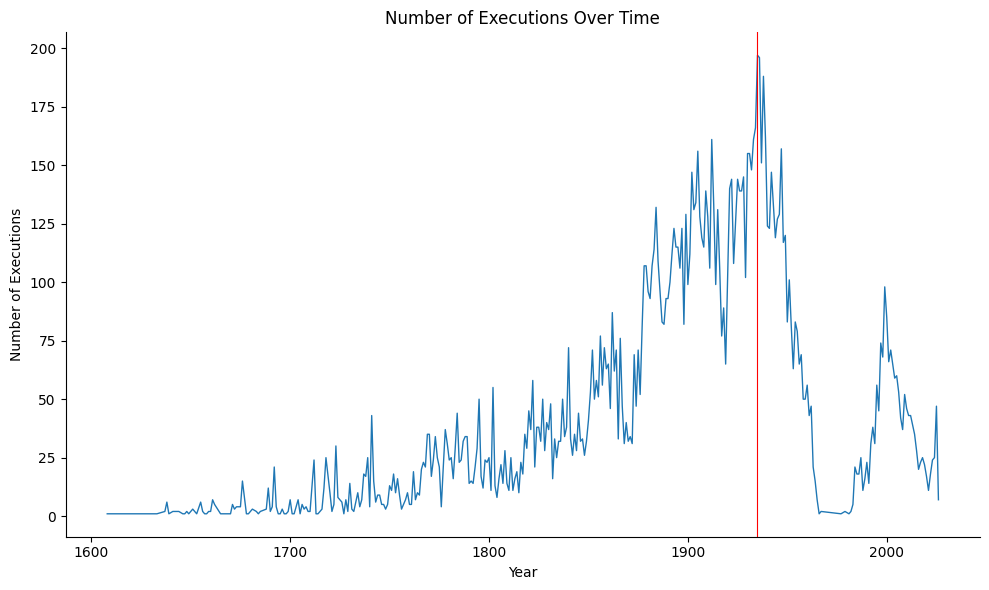

In [25]:
plt.figure(figsize=(10,6))
plt.plot(
    execution_trend.index,
    execution_trend.values,
    linewidth = .99)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Number of Executions Over Time')

ax = plt.gca()
ax1 = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Can you have multiple vertical lines?
ax.axvline(
    1935,
    color = "red",
    linewidth = .8
)

plt.tight_layout()
plt.show()

In [26]:
# get victim race value count
